# Copyright Notice
Copyright 2026 Taiki Miyagawa

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the “Software”), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.

# ✅ Quick Start for Evaluating ARLs and ADDs of Changeoint Detectors

## Important Note
- All sequences are supposed to contain either (1) exclusively pre-change frames or (2) pre-change frames followed by post-change frames. We do not support multiple changepoint detection nor changepoint isolation.
- You need `ls_changepoints` (changepoint indices: 0-based), `ls_durations` (sequence lengths: 1-based), and `ls_predictions` (detection indices: 0-based) to compute the KME-ARL and KME-ADD.
  - Changepoints must set to inf (float("inf") or np.inf) if a sequence does not have a changepoint.
  - Prediction (detection point) must set to -1 if no changepoint was detected.
- We also add some comments in the following for users.

# 1. Generate Sequential Dataset and Detect Changepoints

In [1]:
from ocpdet import CUSUM
import numpy as np

np.random.seed(3141592) 

# User-defined parameters
window_size = 50 # Burn-in size of the window for CUSUM
thresh = 7.5 # Threshold for CUSUM
num_sequences = 10000 # Number of sequences to generate
max_duration = 1000 # Maximum duration of each sequence with variable length
min_duration = 100 # Minimum duration of each sequence with variable length

# Inference (detecting change points)
ls_changepoints = []
ls_durations = []
ls_predictions = []
for _ in range(num_sequences):
    # Randomly generate the duration of the sequence
    it_duration = np.random.randint(min_duration, max_duration) + 1
    ls_durations.append(it_duration)

    # Randomly decide whether to have a changepoint or not
    # If no changepoint, set it to infinity (no change)
    # If there is a changepoint, randomly select its position
    flag_no_change = np.random.choice([True, False], p=[0.5, 0.5])
    if flag_no_change:
        it_changepoint = np.inf
    else:
        it_changepoint = np.random.randint(min_duration, it_duration)
    ls_changepoints.append(it_changepoint)

    # Generate sequence data
    if it_changepoint == np.inf:
        # No change, generate data from a single distribution
        data = np.random.normal(loc=0., scale=0.1, size=(it_duration,))
    else:
        # Change at it_changepoint, generate data from two distributions
        data = np.concatenate([
            np.random.normal(loc=0., scale=0.1, size=(it_changepoint,)),
            np.random.normal(loc=0.1, scale=0.1, size=(it_duration - it_changepoint,))
        ])

    # Process the data with CUSUM
    model = CUSUM(h=thresh, burnin=window_size, mu=0., sigma=0.1)
    model.process(data)
    preds = model.changepoints
    if len(preds) > 0:
        it_pred = preds[0]
    else:
        it_pred = - 1 
    ls_predictions.append(it_pred)

# Output results
print(f"Generated {num_sequences} sequences with variable lengths.")
print(f"Average duration of sequences: {np.mean(ls_durations):.2f}")
print(f"Average changepoint position: {np.mean(ls_changepoints):.2f}.")
print(f"Average predicted changepoint position: {np.mean(ls_predictions):.2f}.")
print(f"Durations: {ls_durations}.")
print(f"Detected changepoints: {ls_changepoints}.")
print(f"Predicted change points: {ls_predictions}.")

Generated 10000 sequences with variable lengths.
Average duration of sequences: 546.57
Average changepoint position: inf.
Average predicted changepoint position: 182.31.
Durations: [877, 400, 1000, 368, 328, 304, 810, 374, 858, 175, 558, 980, 458, 515, 517, 457, 853, 679, 739, 354, 404, 677, 351, 644, 297, 834, 521, 576, 222, 997, 219, 816, 574, 602, 452, 573, 640, 372, 627, 622, 238, 470, 507, 662, 474, 669, 990, 751, 459, 790, 416, 413, 345, 703, 337, 356, 797, 862, 980, 136, 947, 260, 261, 580, 915, 920, 214, 550, 775, 763, 322, 539, 844, 686, 136, 334, 157, 612, 364, 394, 703, 724, 462, 863, 590, 174, 222, 997, 369, 389, 860, 664, 962, 997, 760, 409, 132, 774, 566, 393, 235, 299, 239, 312, 882, 411, 234, 129, 135, 619, 353, 996, 885, 924, 912, 945, 125, 297, 178, 514, 286, 342, 498, 206, 695, 876, 657, 371, 753, 482, 934, 795, 195, 564, 661, 974, 221, 258, 319, 130, 887, 432, 303, 143, 886, 944, 635, 733, 442, 964, 835, 192, 976, 126, 131, 377, 787, 231, 379, 414, 801, 688, 673, 87

### Note
- Now we have `ls_changepoints` (changepoint indices: 0-based), `ls_durations` (sequence lengths: 1-based), and `ls_predictions` (detection indices: 0-based). They will be used to compute the KME-ARL and KME-ADD.
- Changepoints in `ls_changepoints`  must set to inf if a sequence does not have a changepoint.
- Predictions (detected points) in `ls_predictions` must set to -1 if no changepoint was detected.

# 2. Compute ARL
We first compute significantly biased ARL (called LB-ARL in our paper).

In [2]:
from quick_start_toolkit import calc_naive_ARL

naiARL, naisterr, naieffective_num_samples = calc_naive_ARL(
    ls_predictions, ls_changepoints, flag_less_biased=True, flag_verbose=True)

#samples:                   10000
#overruns:                  1284
#samples for computing ARL: 3845
ARL±SE:                     224.49518855656697 ± 2.6516159843544163


`#overruns` means the number of sequences without a detection point, which are not used for computing the LB-ARL and cause unstable and biased estimation.

We next compute our proposed KME-ARL. 

In [3]:
from quick_start_toolkit import calc_KME

kmeARL, kmesterr, kmeeffective_num_samples = calc_KME(
    ls_predictions, ls_changepoints, duration=None, duration_array=ls_durations, flag_verbose=True)

KME-ARL: 303.2259523829064 +/- 2.373468080805263


C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]


This is much closer to the true ARL $ 310.97  +/- 2.63$.

### Note
- `duration` variable is used only when the sequence length is constant; otherwise, set to None, and use `duratoin_array`.
- Please ignore `InregrationWarning`, which `scipy.integrate.quad` in `lifelines` consistently arises.

# 3. Compute ADD
We next compute the ADD

In [4]:
from quick_start_toolkit import calc_naive_ADD

naiADD, sterr, effective_num_samples = calc_naive_ADD(
    ls_predictions, ls_changepoints, flag_verbose=True)

#samples:                   10000
#no alarm samples:          1284
#samples for computing ADD: 2078
ADD±SE:                     8.81087584215592 ± 0.10589145201356658


In [5]:
from quick_start_toolkit import calc_KME_ADD

kmeADD, kmesterr, kmeeffective_num_samples = calc_KME_ADD(
    ls_predictions, ls_changepoints, duration=None, duration_array=ls_durations, flag_verbose=True)

KME-ADD: 8.952077670956232 +/- 0.10377192380451099


C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]


### Note
- `duration` variable is used only when the sequence length is constant; otherwise, set to None, and use `duratoin_array`.
- Please ignore `InregrationWarning`, which `scipy.integrate.quad` in `lifelines` consistently arises.

# Appendix: ARL-ADD Tradeoff Curve
Let's plot ARL-ADD tradeoff curves.

In [6]:
from ocpdet import CUSUM
import numpy as np
from quick_start_toolkit import calc_naive_ADD, calc_naive_ADD
from quick_start_toolkit import calc_KME, calc_KME_ADD

np.random.seed(3141592)  

# User-defined parameters
window_size = 50 # Burn-in size of the window for CUSUM
num_sequences = 300 # Number of sequences to generate
max_duration = 1000 # Maximum duration of each sequence with variable length
min_duration = 100 # Minimum duration of each sequence with variable length
ls_thresholds = [4., 8., 12., 16., 20.]  # Different thresholds to test

# Start estimating ARL and ADD for different thresholds
ls_LB_ARL = []
ls_LB_ADD = []
ls_KME_ARL = []
ls_KME_ADD = []
ls_LB_ARLerr = []
ls_LB_ADDerr = []
ls_KME_ARLerr = []
ls_KME_ADDerr = []
for thresh in ls_thresholds:
    print(f"Processing with threshold: {thresh}")

    # Inference (detecting change points)
    ls_changepoints = []
    ls_durations = []
    ls_predictions = []
    for _ in range(num_sequences):
        # Randomly generate the duration of the sequence
        it_duration = np.random.randint(min_duration, max_duration) + 1
        ls_durations.append(it_duration)

        # Randomly decide whether to have a changepoint or not
        # If no changepoint, set it to infinity (no change)
        # If there is a changepoint, randomly select its position
        flag_no_change = np.random.choice([True, False], p=[0.5, 0.5])
        if flag_no_change:
            it_changepoint = np.inf
        else:
            it_changepoint = np.random.randint(min_duration, it_duration)
        ls_changepoints.append(it_changepoint)

        # Generate sequence data
        if it_changepoint == np.inf:
            # No change, generate data from a single distribution
            data = np.random.normal(loc=0., scale=0.1, size=(it_duration,))
        else:
            # Change at it_changepoint, generate data from two distributions
            data = np.concatenate([
                np.random.normal(loc=0., scale=0.1, size=(it_changepoint,)),
                np.random.normal(loc=0.1, scale=0.1, size=(it_duration - it_changepoint,))
            ])

        # Process the data with CUSUM
        model = CUSUM(h=thresh, burnin=window_size, mu=0., sigma=0.1)
        model.process(data)
        preds = model.changepoints
        if len(preds) > 0:
            it_pred = preds[0]
        else:
            it_pred = - 1 
        ls_predictions.append(it_pred)

    # Compute ARL and ADD
    naiARL, naisterr, naieffective_num_samples = calc_naive_ARL(
        ls_predictions, ls_changepoints, flag_less_biased=True, flag_verbose=False)

    kmeARL, kmesterr, kmeeffective_num_samples = calc_KME(
        ls_predictions, ls_changepoints, duration=None, duration_array=ls_durations, flag_verbose=False)

    naiADD, sterr, effective_num_samples = calc_naive_ADD(
        ls_predictions, ls_changepoints, flag_verbose=False)

    kmeADD, kmesterr, kmeeffective_num_samples = calc_KME_ADD(
        ls_predictions, ls_changepoints, duration=None, duration_array=ls_durations, flag_verbose=False)
    
    # Store results
    ls_LB_ARL.append(naiARL)
    ls_LB_ADD.append(naiADD)
    ls_KME_ARL.append(kmeARL)
    ls_KME_ADD.append(kmeADD)
    ls_LB_ARLerr.append(naisterr)
    ls_LB_ADDerr.append(sterr)
    ls_KME_ARLerr.append(kmesterr)
    ls_KME_ADDerr.append(kmesterr)

Processing with threshold: 4.0


C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]


Processing with threshold: 8.0


C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]
C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the li

Processing with threshold: 12.0


C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]
C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the li

Processing with threshold: 16.0


C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]
C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the li

Processing with threshold: 20.0


C:\Users\chopi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]


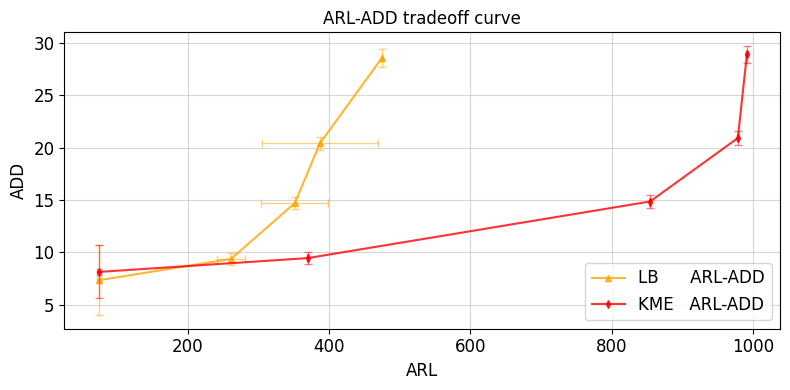

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.title(f"ARL-ADD tradeoff curve")

# LB ARL-ADD line with error bars
plt.plot(ls_LB_ARL, ls_LB_ADD,
         marker="^", markersize=4, linestyle="-", color="orange", label="LB      ARL-ADD", alpha=0.8)
plt.errorbar(ls_LB_ARL, ls_LB_ADD, 
             xerr=ls_LB_ARLerr, yerr=ls_LB_ADDerr, 
             fmt='none', capsize=3, capthick=1, elinewidth=1, color="orange", alpha=0.5)

# KME ARL-ADD line with error bars
plt.plot(ls_KME_ARL, ls_KME_ADD,
         marker="d", markersize=4, linestyle="-", color="red", label="KME   ARL-ADD", alpha=0.8)
plt.errorbar(ls_KME_ARL, ls_KME_ADD, 
             xerr=ls_KME_ARLerr, yerr=ls_KME_ADDerr, 
             fmt='none', capsize=3, capthick=1, elinewidth=1, color="red", alpha=0.5)

# if duration < 500 and statistic_type == "GSR":
#     plt.axvline(x=duration, color='green', linestyle='--', label="Max duration", alpha=0.7)
#     plt.axvspan(duration, 450, alpha=0.2, color='gray', label="Extrapolation region") 
# elif duration < 300 and statistic_type == "CUSUM":
#     plt.axvline(x=duration, color='green', linestyle='--', label="Max duration", alpha=0.7)
#     plt.axvspan(duration, 210, alpha=0.2, color='gray', label="Extrapolation region")

plt.grid(alpha=0.5)
plt.xlabel("ARL", fontsize=12)
plt.ylabel("ADD", fontsize=12)
plt.tick_params(axis='both', which='both', labelsize=12)
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()